In [100]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [101]:
# Check the dataset structure

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (9800, 18)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Data Types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11

In [102]:
# Create a copy for cleaning
sales = df.copy()

# Convert date columns to datetime
sales["Order Date"] = pd.to_datetime(
    sales["Order Date"], dayfirst=True
)

sales["Ship Date"] = pd.to_datetime(
    sales["Ship Date"], dayfirst=True
)

# Remove leading/trailing spaces from text columns
text_columns = sales.select_dtypes(include="object").columns

for column in text_columns:
    sales[column] = sales[column].str.strip()

# Handle missing Postal Code values
sales["Postal Code"] = sales["Postal Code"].fillna(0)

# Check the cleaned dataset
print("Dataset shape:", sales.shape)
print("Duplicate rows:", sales.duplicated().sum())
print("Missing values:")
print(sales.isnull().sum())

Dataset shape: (9800, 18)
Duplicate rows: 0
Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


C:\Users\heman\AppData\Local\Temp\ipykernel_1800\4053624718.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = sales.select_dtypes(include="object").columns


In [103]:
# ==============================
# TASK 1 - KEY PERFORMANCE INDICATORS
# ==============================

total_sales = sales["Sales"].sum()
total_orders = sales["Order ID"].nunique()
total_customers = sales["Customer ID"].nunique()
average_order_value = total_sales / total_orders

print("===== KEY PERFORMANCE INDICATORS =====")
print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Customers   : {total_customers:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")

===== KEY PERFORMANCE INDICATORS =====
Total Sales       : $2,261,536.78
Total Orders      : 4,922
Total Customers   : 793
Average Order Value: $459.48


In [104]:
# ==============================
# TASK 1 - KEY PERFORMANCE INDICATORS
# ==============================

total_sales = sales["Sales"].sum()
total_orders = sales["Order ID"].nunique()
total_customers = sales["Customer ID"].nunique()
average_order_value = total_sales / total_orders

print("===== KEY PERFORMANCE INDICATORS =====")
print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Customers   : {total_customers:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")

===== KEY PERFORMANCE INDICATORS =====
Total Sales       : $2,261,536.78
Total Orders      : 4,922
Total Customers   : 793
Average Order Value: $459.48


In [105]:
# ==============================
# SALES TREND ANALYSIS
# ==============================

# Create Year and Month columns
sales["Year"] = sales["Order Date"].dt.year
sales["Month"] = sales["Order Date"].dt.month

# Sales by year
yearly_sales = sales.groupby("Year")["Sales"].sum()

print("===== YEARLY SALES =====")
print(yearly_sales)

# Sales by month
monthly_sales = sales.groupby("Month")["Sales"].sum()

print("\n===== MONTHLY SALES =====")
print(monthly_sales)

===== YEARLY SALES =====
Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

===== MONTHLY SALES =====
Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64


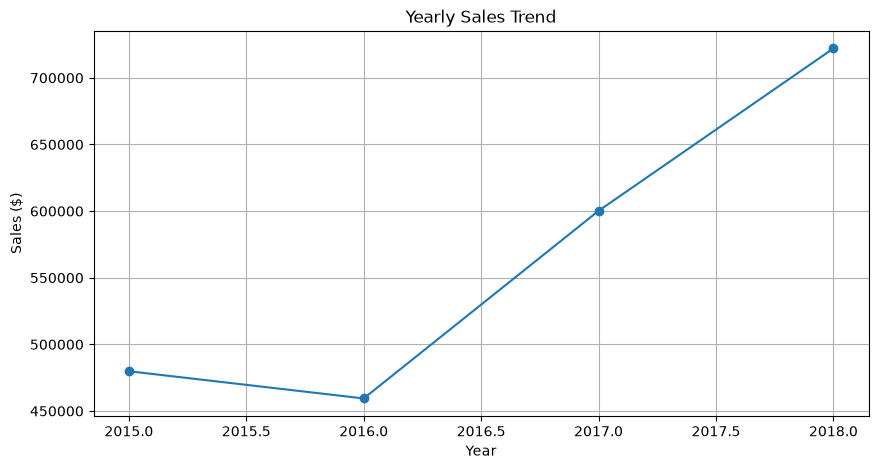

In [106]:
import matplotlib.pyplot as plt

# Yearly Sales Trend
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker="o"
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.grid(True)

plt.show()

In [107]:
# ==============================
# PRODUCT & CATEGORY ANALYSIS
# ==============================

# Top 10 products by sales
top_products = (
    sales.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("===== TOP 10 PRODUCTS =====")
print(top_products)

# Sales by category
category_sales = (
    sales.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\n===== SALES BY CATEGORY =====")
print(category_sales)

# Sales by sub-category
subcategory_sales = (
    sales.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\n===== SALES BY SUB-CATEGORY =====")
print(subcategory_sales)


===== TOP 10 PRODUCTS =====
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

===== SALES BY CATEGORY =====
Category
T

In [108]:
# ==============================
# TOP 10 PRODUCTS - FULL OUTPUT
# ==============================

print("TOP 10 PRODUCTS BY SALES")
print("-" * 60)

for i, (product, value) in enumerate(top_products.items(), 1):
    print(f"{i}. {product}")
    print(f"   Sales: ${value:,.2f}\n")

TOP 10 PRODUCTS BY SALES
------------------------------------------------------------
1. Canon imageCLASS 2200 Advanced Copier
   Sales: $61,599.82

2. Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind
   Sales: $27,453.38

3. Cisco TelePresence System EX90 Videoconferencing Unit
   Sales: $22,638.48

4. HON 5400 Series Task Chairs for Big and Tall
   Sales: $21,870.58

5. GBC DocuBind TL300 Electric Binding System
   Sales: $19,823.48

6. GBC Ibimaster 500 Manual ProClick Binding System
   Sales: $19,024.50

7. Hewlett Packard LaserJet 3310 Copier
   Sales: $18,839.69

8. HP Designjet T520 Inkjet Large Format Printer - 24" Color
   Sales: $18,374.90

9. GBC DocuBind P400 Electric Binding System
   Sales: $17,965.07

10. High Speed Automatic Electric Letter Opener
   Sales: $17,030.31



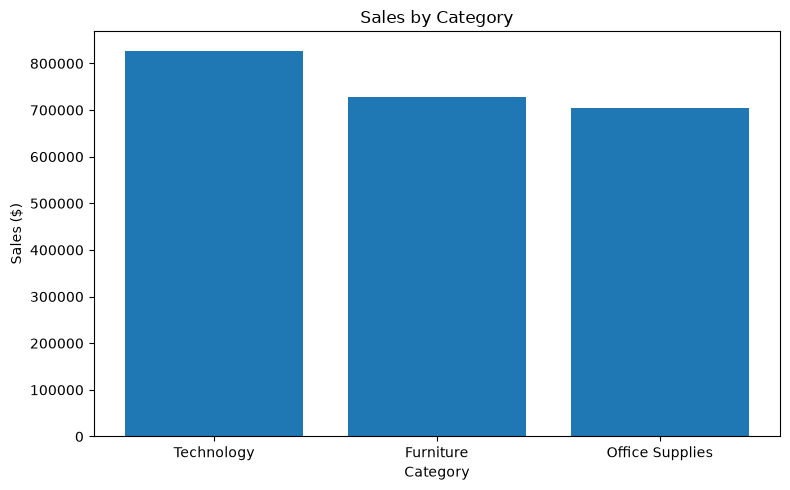

In [109]:
# ==============================
# SALES BY CATEGORY
# ==============================

plt.figure(figsize=(8, 5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()


In [110]:
# ==============================
# SALES BY REGION
# ==============================

region_sales = sales.groupby("Region")["Sales"].sum()

print("===== SALES BY REGION =====")
print(region_sales)

===== SALES BY REGION =====
Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


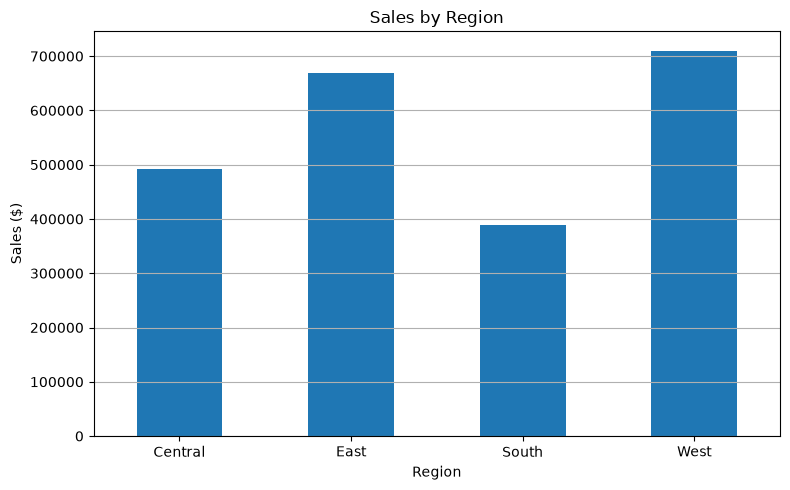

In [111]:
# ==============================
# SALES BY REGION CHART
# ==============================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.show()


===== SALES BY CATEGORY =====
Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


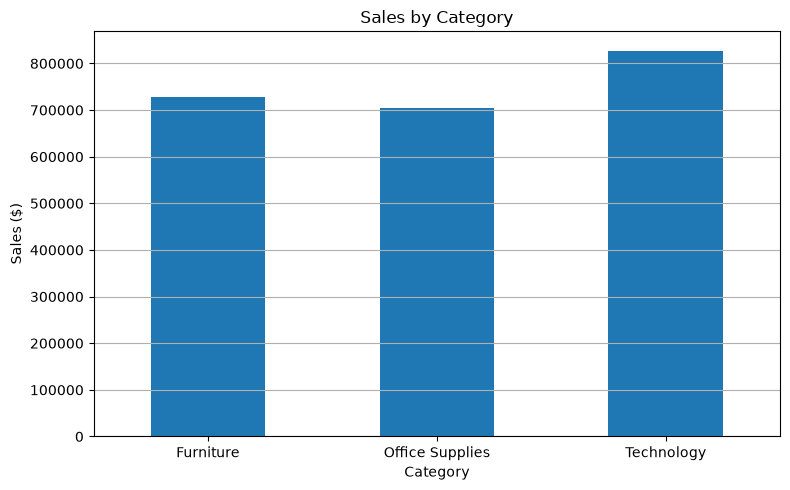

In [112]:
# ==============================
# SALES BY CATEGORY CHART
# ==============================

category_sales = sales.groupby("Category")["Sales"].sum()

print("===== SALES BY CATEGORY =====")
print(category_sales)

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

===== SALES BY SUB-CATEGORY =====
Sub-Category
Accessories    164186.7000
Appliances     104618.4030
Art             26705.4100
Binders        200028.7850
Bookcases      113813.1987
Chairs         322822.7310
Copiers        146248.0940
Envelopes       16128.0460
Fasteners        3001.9600
Furnishings     89212.0180
Labels          12347.7260
Machines       189238.6310
Paper           76828.3040
Phones         327782.4480
Storage        219343.3920
Supplies        46420.3080
Tables         202810.6280
Name: Sales, dtype: float64


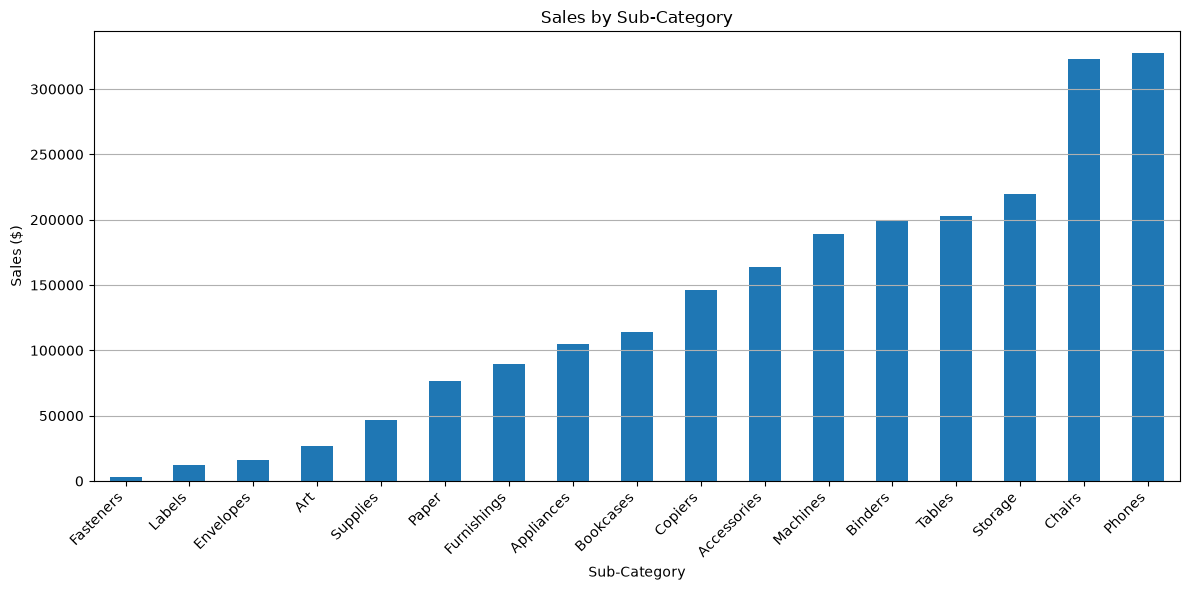

In [113]:
# ==============================
# SALES BY SUB-CATEGORY CHART
# ==============================

subcategory_sales = sales.groupby("Sub-Category")["Sales"].sum()

print("===== SALES BY SUB-CATEGORY =====")
print(subcategory_sales)

plt.figure(figsize=(12, 6))

subcategory_sales.sort_values().plot(kind="bar")

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()

plt.show()

===== SALES BY SUB-CATEGORY =====
Sub-Category
Accessories    164186.7000
Appliances     104618.4030
Art             26705.4100
Binders        200028.7850
Bookcases      113813.1987
Chairs         322822.7310
Copiers        146248.0940
Envelopes       16128.0460
Fasteners        3001.9600
Furnishings     89212.0180
Labels          12347.7260
Machines       189238.6310
Paper           76828.3040
Phones         327782.4480
Storage        219343.3920
Supplies        46420.3080
Tables         202810.6280
Name: Sales, dtype: float64


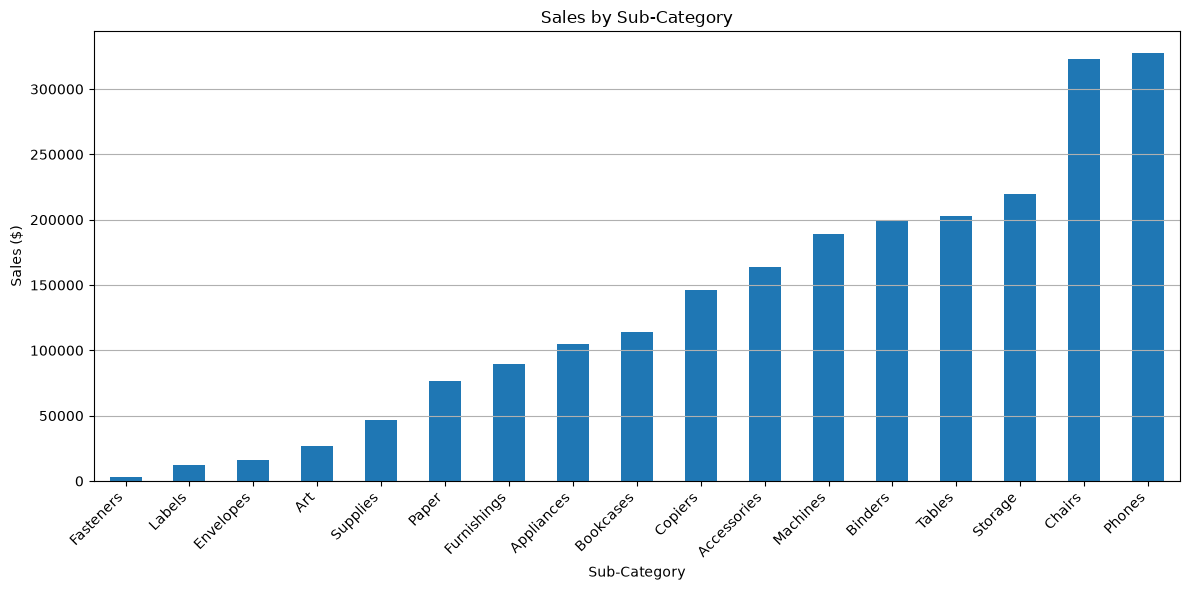

In [114]:
# ==============================
# SALES BY SUB-CATEGORY
# ==============================

subcategory_sales = sales.groupby("Sub-Category")["Sales"].sum()

print("===== SALES BY SUB-CATEGORY =====")
print(subcategory_sales)

plt.figure(figsize=(12, 6))

subcategory_sales.sort_values().plot(kind="bar")

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()

plt.show()

===== TOP 10 PRODUCTS BY SALES =====
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


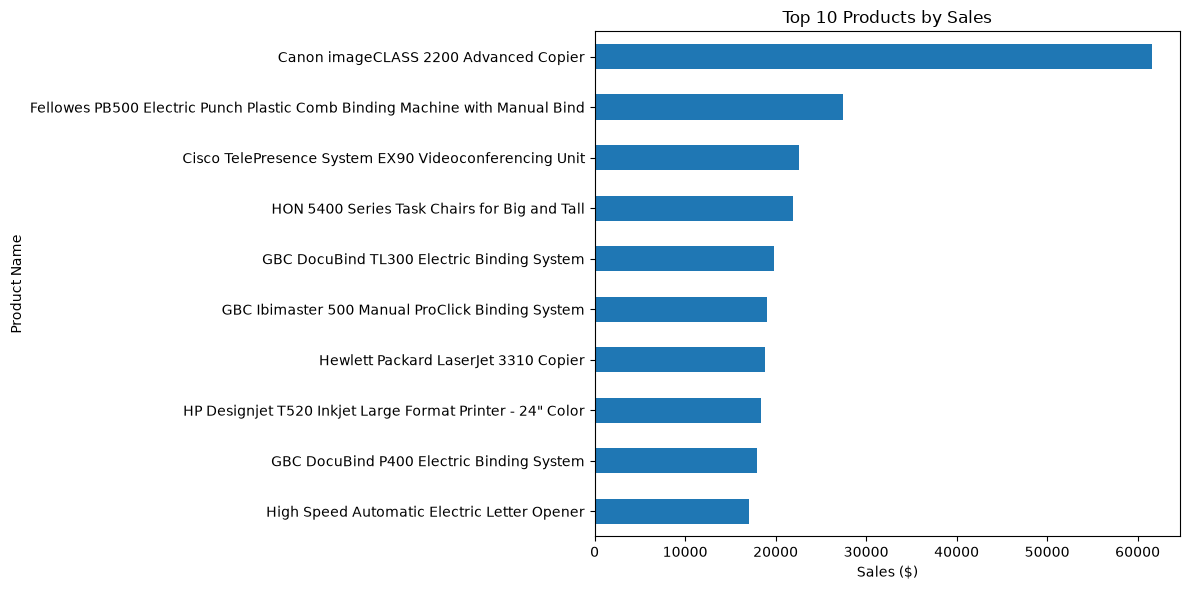

In [115]:
# ==============================
# TOP 10 PRODUCTS BY SALES
# ==============================

top_products = (
    sales.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("===== TOP 10 PRODUCTS BY SALES =====")
print(top_products)

plt.figure(figsize=(12, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Product Name")
plt.tight_layout()

plt.show()

===== SALES BY SEGMENT =====
Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


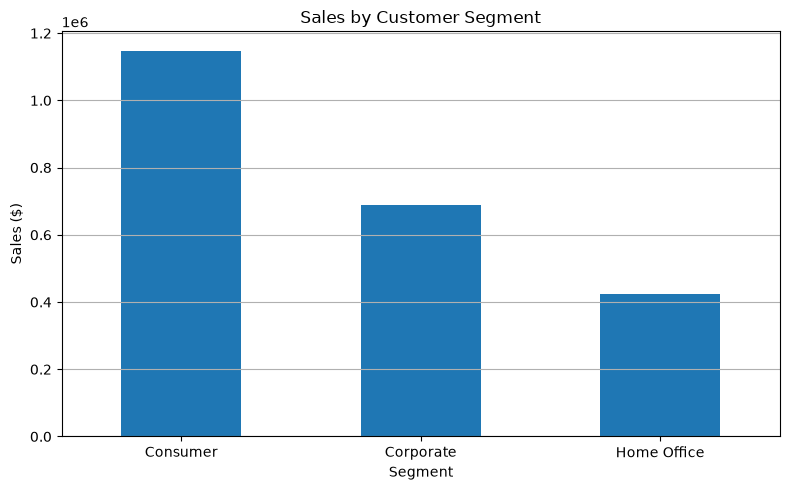

In [116]:
# ==============================
# SALES BY SEGMENT
# ==============================

segment_sales = sales.groupby("Segment")["Sales"].sum()

print("===== SALES BY SEGMENT =====")
print(segment_sales)

plt.figure(figsize=(8, 5))

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

===== TOP 10 STATES BY SALES =====
State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


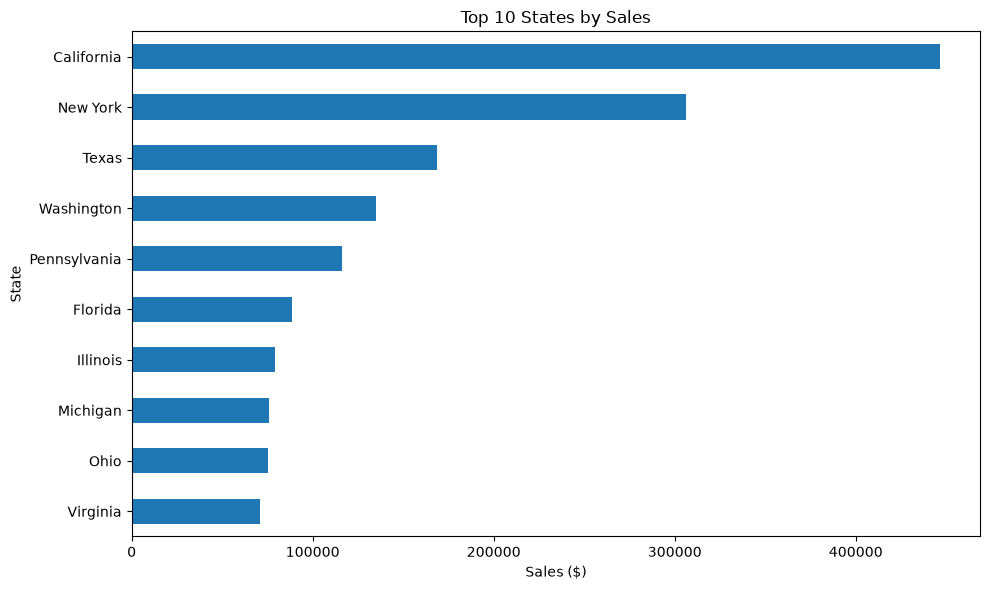

In [117]:
# ==============================
# TOP 10 STATES BY SALES
# ==============================

state_sales = (
    sales.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("===== TOP 10 STATES BY SALES =====")
print(state_sales)

plt.figure(figsize=(10, 6))

state_sales.sort_values().plot(kind="barh")

plt.title("Top 10 States by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("State")
plt.tight_layout()

plt.show()

In [118]:
# ==============================
# TOTAL PROFIT
# ==============================

total_profit = sales["Profit"].sum()

print("===== TOTAL PROFIT =====")
print(f"${total_profit:,.2f}")

KeyError: 'Profit'

In [119]:
print(sales.columns.tolist())


['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month']


In [120]:
for col in sales.columns:
    print(col)

Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Year
Month


In [121]:
# ==============================
# TOTAL SALES
# ==============================

total_sales = sales["Sales"].sum()

print("===== TOTAL SALES =====")
print(f"${total_sales:,.2f}")

===== TOTAL SALES =====
$2,261,536.78


In [122]:
# ==============================
# SALES BY SEGMENT
# ==============================

segment_sales = sales.groupby("Segment")["Sales"].sum()

print("===== SALES BY SEGMENT =====")
print(segment_sales)

===== SALES BY SEGMENT =====
Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


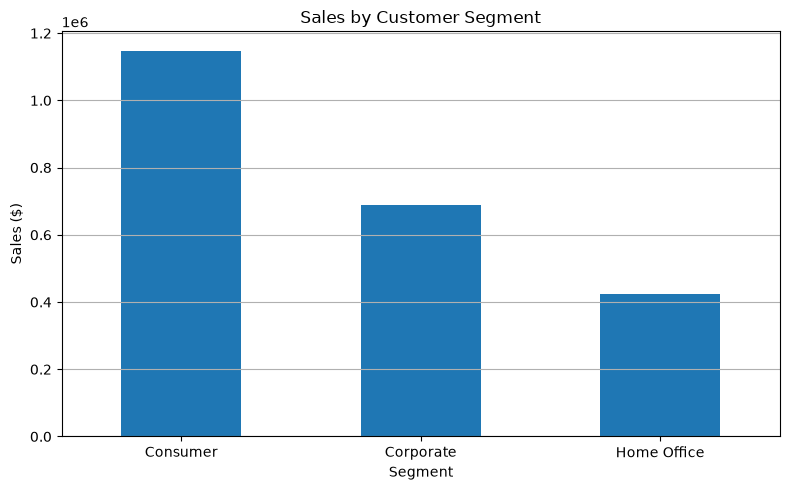

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [124]:
# ==============================
# TOP 10 STATES BY SALES
# ==============================

state_sales = sales.groupby("State")["Sales"].sum()
top_states = state_sales.sort_values(ascending=False).head(10)

print("===== TOP 10 STATES BY SALES =====")
print(top_states)

===== TOP 10 STATES BY SALES =====
State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


In [125]:
# ==============================
# SALES BY SHIP MODE
# ==============================

ship_mode_sales = sales.groupby("Ship Mode")["Sales"].sum()

print("===== SALES BY SHIP MODE =====")
print(ship_mode_sales)

===== SALES BY SHIP MODE =====
Ship Mode
First Class       3.455723e+05
Same Day          1.252190e+05
Second Class      4.499142e+05
Standard Class    1.340831e+06
Name: Sales, dtype: float64


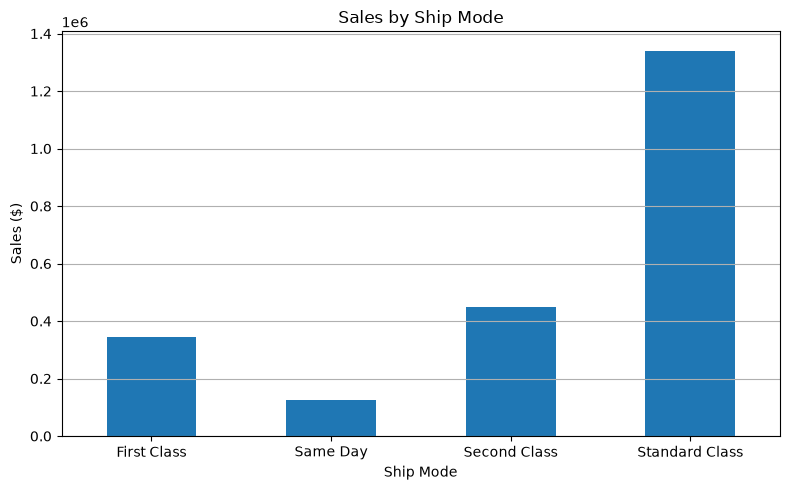

In [126]:
plt.figure(figsize=(8, 5))

ship_mode_sales.plot(kind="bar")

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [127]:
# ==============================
# TOP 10 CITIES BY SALES
# ==============================

city_sales = sales.groupby("City")["Sales"].sum()

top_cities = city_sales.sort_values(ascending=False).head(10)

print("===== TOP 10 CITIES BY SALES =====")
print(top_cities)

===== TOP 10 CITIES BY SALES =====
City
New York City    252462.5470
Los Angeles      173420.1810
Seattle          116106.3220
San Francisco    109041.1200
Philadelphia     108841.7490
Houston           63956.1428
Chicago           47820.1330
San Diego         47521.0290
Jacksonville      44713.1830
Detroit           42446.9440
Name: Sales, dtype: float64


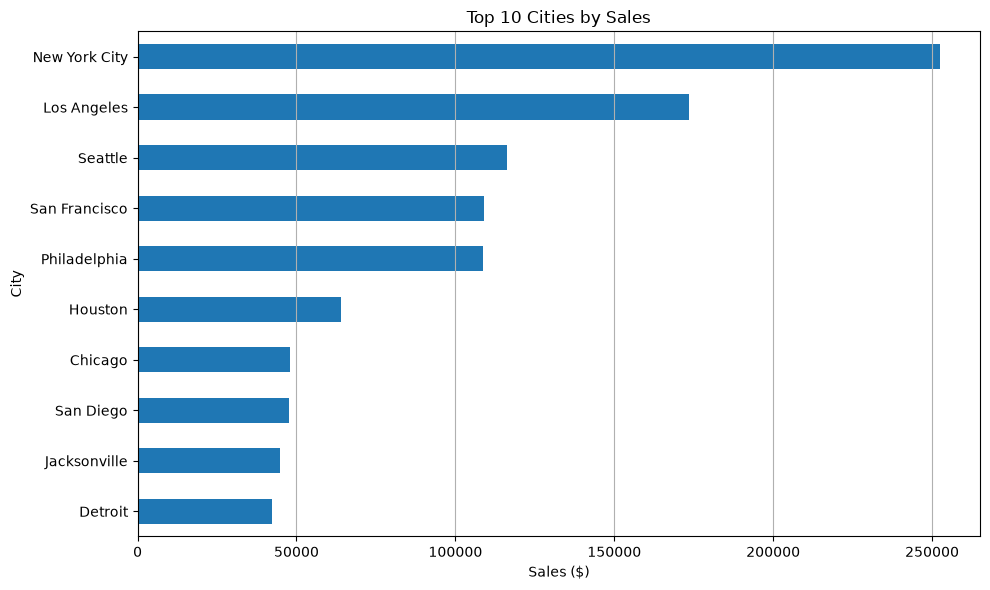

In [128]:
plt.figure(figsize=(10, 6))

top_cities.sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("City")
plt.grid(axis="x")
plt.tight_layout()

plt.show()

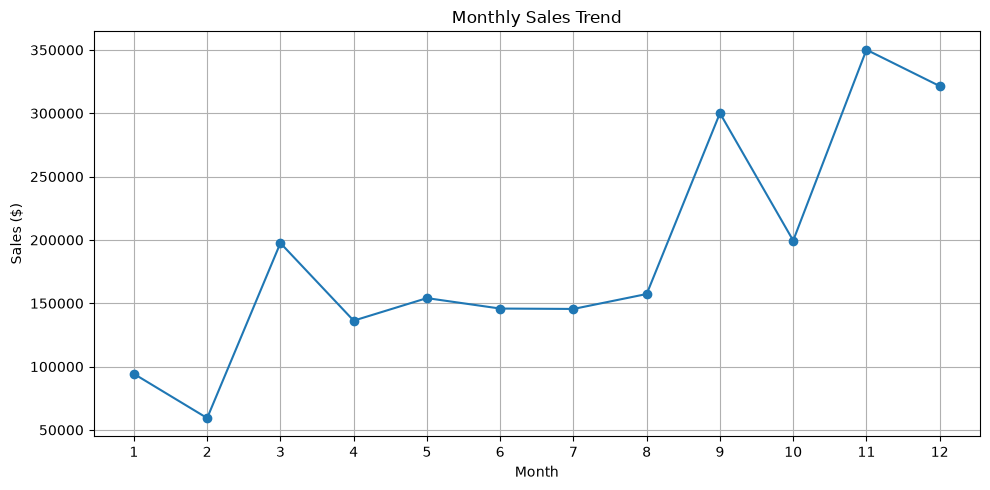

In [129]:
# ==============================
# MONTHLY SALES TREND
# ==============================

monthly_sales = sales.groupby("Month")["Sales"].sum()

plt.figure(figsize=(10, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()

plt.show()

In [130]:
# ==============================
# TOP 10 CUSTOMERS BY SALES
# ==============================

customer_sales = sales.groupby("Customer Name")["Sales"].sum()

top_customers = customer_sales.sort_values(ascending=False).head(10)

print("===== TOP 10 CUSTOMERS BY SALES =====")
print(top_customers)

===== TOP 10 CUSTOMERS BY SALES =====
Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


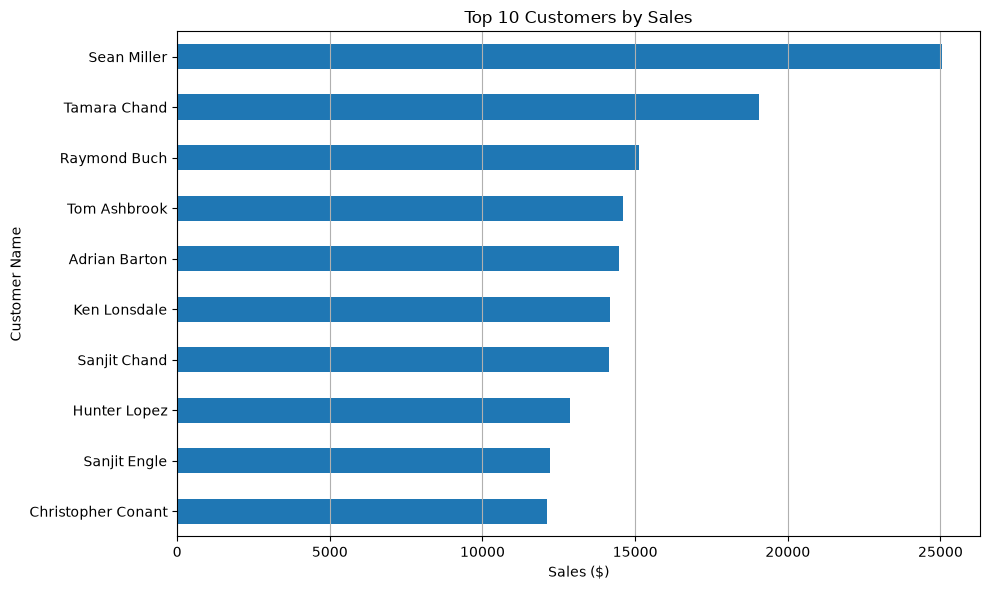

In [131]:
plt.figure(figsize=(10, 6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Customer Name")
plt.grid(axis="x")
plt.tight_layout()

plt.show()

In [132]:
# ==============================
# AVERAGE SALES PER ORDER
# ==============================

average_sales = sales["Sales"].mean()

print("===== AVERAGE SALES PER ORDER =====")
print(f"${average_sales:,.2f}")

===== AVERAGE SALES PER ORDER =====
$230.77


In [133]:
# ==============================
# TOTAL NUMBER OF ORDERS
# ==============================

total_orders = sales["Order ID"].nunique()

print("===== TOTAL ORDERS =====")
print(total_orders)

===== TOTAL ORDERS =====
4922


In [134]:
# ==============================
# SHIPPING TIME ANALYSIS
# ==============================

sales["Order Date"] = pd.to_datetime(
    sales["Order Date"],
    dayfirst=True,
    errors="coerce"
)

sales["Ship Date"] = pd.to_datetime(
    sales["Ship Date"],
    dayfirst=True,
    errors="coerce"
)

sales["Shipping Days"] = (
    sales["Ship Date"] - sales["Order Date"]
).dt.days

average_shipping = sales["Shipping Days"].mean()

print("===== AVERAGE SHIPPING TIME =====")
print(f"{average_shipping:.2f} days")


===== AVERAGE SHIPPING TIME =====
3.96 days


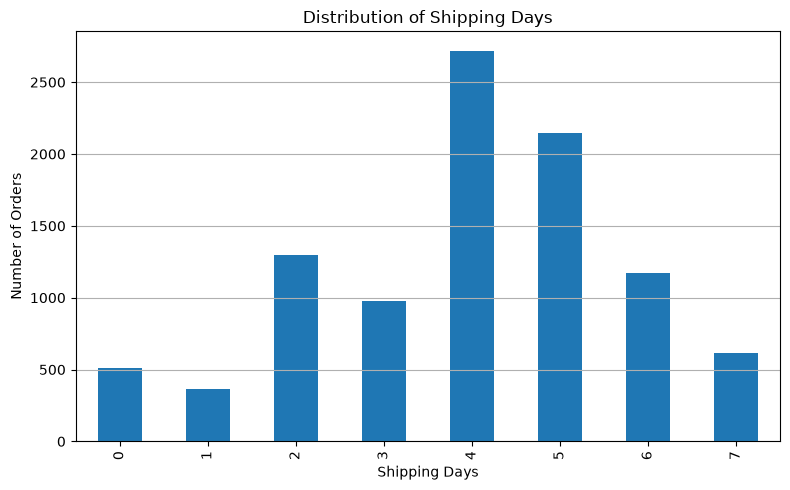

In [135]:
plt.figure(figsize=(8, 5))

sales["Shipping Days"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Shipping Days")
plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [136]:
# ==============================
# FINAL KPI SUMMARY
# ==============================

total_sales = sales["Sales"].sum()
total_orders = sales["Order ID"].nunique()
total_customers = sales["Customer ID"].nunique()
average_order_value = total_sales / total_orders

best_year = yearly_sales.idxmax()
best_year_sales = yearly_sales.max()

best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

best_region = region_sales.idxmax()
best_region_sales = region_sales.max()

best_subcategory = subcategory_sales.idxmax()
best_subcategory_sales = subcategory_sales.max()

print("========== TASK 1 KPI SUMMARY ==========")
print(f"Total Sales        : ${total_sales:,.2f}")
print(f"Total Orders       : {total_orders:,}")
print(f"Total Customers    : {total_customers:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Best Sales Year    : {best_year} (${best_year_sales:,.2f})")
print(f"Best Category      : {best_category} (${best_category_sales:,.2f})")
print(f"Best Region        : {best_region} (${best_region_sales:,.2f})")
print(f"Best Sub-Category  : {best_subcategory} (${best_subcategory_sales:,.2f})")

========== TASK 1 KPI SUMMARY ==========
Total Sales        : $2,261,536.78
Total Orders       : 4,922
Total Customers    : 793
Average Order Value: $459.48
Best Sales Year    : 2018 ($722,052.02)
Best Category      : Technology ($827,455.87)
Best Region        : West ($710,219.68)
Best Sub-Category  : Phones ($327,782.45)
